In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from keras import regularizers
from scipy.stats import zscore

In [ ]:
#Just to download file
path = kagglehub.dataset_download("hellbuoy/car-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/hellbuoy/car-price-prediction/versions/1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
car_df = pd.read_csv('/content/drive/MyDrive/Year 3/Data Science Applied Machine Learning/CarPrice Manish Kumar (hellbuoy)/CarPrice_Assignment - CarPrice_Assignment.csv')

In [ ]:
print(car_df.columns)
print(car_df.describe())
print(car_df.info()) #print car DataFrame info

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carh8', 'curbw8', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')
           car_ID   symboling  doornumber   wheelbase   carlength    carwidth  \
count  205.000000  205.000000  205.000000  205.000000  205.000000  205.000000   
mean   103.000000    0.834146    3.121951   98.756585  174.049268   65.907805   
std     59.322565    1.245307    0.994966    6.021776   12.337289    2.145204   
min      1.000000   -2.000000    2.000000   86.600000  141.100000   60.300000   
25%     52.000000    0.000000    2.000000   94.500000  166.300000   64.100000   
50%    103.000000    1.000000    4.000000   97.000000  173.200000   65.500000   
75%    154.000000    2.000000   

In [ ]:
car_df = car_df.drop('car_ID', axis=1) #dropping car_ID since that is irrelevant to the price

In [ ]:
# Extracting Car Company from the CarName as per direction in Problem
car_df['CarName'].str.split(' ',expand=True)
print(car_df['CarName'])
car_df['CarName'] = car_df['CarName'].str.split(' ',expand=True)[0]
print(car_df['CarName'].unique())

0            alfa-romero giulia
1           alfa-romero stelvio
2      alfa-romero Quadrifoglio
3                   audi 100 ls
4                    audi 100ls
                 ...           
200             volvo 145e (sw)
201                 volvo 144ea
202                 volvo 244dl
203                   volvo 246
204                 volvo 264gl
Name: CarName, Length: 205, dtype: object
['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'maxda' 'mazda' 'buick' 'mercury' 'mitsubishi' 'Nissan' 'nissan'
 'peugeot' 'plymouth' 'porsche' 'porcshce' 'renault' 'saab' 'subaru'
 'toyota' 'toyouta' 'vokswagen' 'volkswagen' 'vw' 'volvo']


In [ ]:
car_df['CarName'] = car_df['CarName'].replace({'maxda':'mazda',
                                               'nissan':'Nissan',
                                               'porcshce':'porsche',
                                               'toyouta':'toyota',
                                               'vokswagen':'volkswagen',
                                               'vw':'volkswagen'})
print(car_df['CarName'].unique())

['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'buick' 'mercury' 'mitsubishi' 'Nissan' 'peugeot' 'plymouth'
 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen' 'volvo']


In [ ]:
print(car_df.columns)
print(car_df.describe())
print(car_df.info()) #print car DataFrame info again

Index(['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber',
       'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carh8', 'curbw8', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')
        symboling  doornumber   wheelbase   carlength    carwidth       carh8  \
count  205.000000  205.000000  205.000000  205.000000  205.000000  205.000000   
mean     0.834146    3.121951   98.756585  174.049268   65.907805   53.724878   
std      1.245307    0.994966    6.021776   12.337289    2.145204    2.443522   
min     -2.000000    2.000000   86.600000  141.100000   60.300000   47.800000   
25%      0.000000    2.000000   94.500000  166.300000   64.100000   52.000000   
50%      1.000000    4.000000   97.000000  173.200000   65.500000   54.100000   
75%      2.000000    4.000000  102.400000  183.10

In [ ]:
# encode the object parts of the dataset so that it is numbers instead
label_encoders = {}
for col in ['CarName', 'fueltype', 'aspiration', 'carbody',
            'drivewheel', 'enginelocation', 'enginetype', 'fuelsystem']:
  le = LabelEncoder()
  car_df[col] = le.fit_transform(car_df[col])
  label_encoders[col] = le

print(car_df.columns)
print(car_df.describe())
print(car_df.info()) #print car DataFrame info

Index(['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber',
       'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carh8', 'curbw8', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')
        symboling     CarName    fueltype  aspiration  doornumber     carbody  \
count  205.000000  205.000000  205.000000  205.000000  205.000000  205.000000   
mean     0.834146   11.580488    0.902439    0.180488    3.121951    2.614634   
std      1.245307    6.881320    0.297446    0.385535    0.994966    0.859081   
min     -2.000000    0.000000    0.000000    0.000000    2.000000    0.000000   
25%      0.000000    6.000000    1.000000    0.000000    2.000000    2.000000   
50%      1.000000   12.000000    1.000000    0.000000    4.000000    3.000000   
75%      2.000000   19.000000    1.000000    0.00

In [ ]:
# Calculate zscore to remove those too far out of standard deviation and print it out
# zScores = np.abs(zscore(car_df))
# zScores.describe()

In [ ]:
# # Remove rows that are too far from standard deviation
# zScores = np.abs(zscore(car_df))
# car_df = car_df[(zScores < 3).all(axis=1)]
# print(car_df.shape)

In [ ]:
print(car_df.describe())
print(car_df.info()) #print car DataFrame info

        symboling     CarName    fueltype  aspiration  doornumber     carbody  \
count  205.000000  205.000000  205.000000  205.000000  205.000000  205.000000   
mean     0.834146   11.580488    0.902439    0.180488    3.121951    2.614634   
std      1.245307    6.881320    0.297446    0.385535    0.994966    0.859081   
min     -2.000000    0.000000    0.000000    0.000000    2.000000    0.000000   
25%      0.000000    6.000000    1.000000    0.000000    2.000000    2.000000   
50%      1.000000   12.000000    1.000000    0.000000    4.000000    3.000000   
75%      2.000000   19.000000    1.000000    0.000000    4.000000    3.000000   
max      3.000000   21.000000    1.000000    1.000000    4.000000    4.000000   

       drivewheel  enginelocation   wheelbase   carlength  ...  enginesize  \
count  205.000000      205.000000  205.000000  205.000000  ...  205.000000   
mean     1.326829        0.014634   98.756585  174.049268  ...  126.907317   
std      0.556171        0.120377   

In [ ]:
# separate features and label
X = car_df.drop(columns=['price'])
y = car_df['price'].values
print(X)
print(y)

     symboling  CarName  fueltype  aspiration  doornumber  carbody  \
0            3        1         1           0           2        0   
1            3        1         1           0           2        0   
2            1        1         1           0           2        2   
3            2        2         1           0           4        3   
4            2        2         1           0           4        3   
..         ...      ...       ...         ...         ...      ...   
200         -1       21         1           0           4        3   
201         -1       21         1           1           4        3   
202         -1       21         1           0           4        3   
203         -1       21         0           1           4        3   
204         -1       21         1           1           4        3   

     drivewheel  enginelocation  wheelbase  carlength  ...  cylindernumber  \
0             2               0       88.6      168.8  ...               4   
1  

In [ ]:
#scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

###Linear Regression

In [ ]:
# trying different linear regression models
x_model = linear_model.LinearRegression()
x_model.fit(X, y)
coeffs_Xlr = np.array(list(x_model.intercept_.flatten()) + list(x_model.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)

x_model2 = linear_model.RidgeCV(alphas=[0.8, 1.0, 10.0])
x_model2.fit(X, y)
coeffs_XRCVr = np.array(list(x_model2.intercept_.flatten()) + list(x_model2.coef_.flatten()))
coeffs_XRCVr = list(coeffs_XRCVr)

x_model3 = linear_model.ElasticNet(alpha=3.0, l1_ratio=1)
x_model3.fit(X, y)
coeffs_XENr = np.array(list(x_model3.intercept_.flatten()) + list(x_model3.coef_.flatten()))
coeffs_XENr = list(coeffs_XENr)

x_model4 = linear_model.ARDRegression()
x_model4.fit(X, y)
coeffs_XARDr = np.array(list(x_model4.intercept_.flatten()) + list(x_model4.coef_.flatten()))
coeffs_XARDr = list(coeffs_XARDr)

x_model5 = linear_model.SGDRegressor()
x_model5.fit(X, y)
coeffs_XSGDr = np.array(list(x_model5.intercept_.flatten()) + list(x_model5.coef_.flatten()))
coeffs_XSGDr = list(coeffs_XSGDr)

In [ ]:
# Rounding and printing their score
Xlr_rsq = round(x_model.score(X, y), 4)
XRCVr_rsq = round(x_model2.score(X, y), 4)
XENr_rsq = round(x_model3.score(X, y), 4)
XARDr_rsq = round(x_model4.score(X, y), 4)
XSGDr_rsq = round(x_model5.score(X, y), 4)

print("\nX simple linear regression R-square :", Xlr_rsq)
print("\n")
print("\nX RidgeCV linear regression R-square :", XRCVr_rsq)
print("\n")
print("\nX ElasticNet linear regression R-square :", XENr_rsq)
print("\n")
print("\nX ARDRegression linear regression R-square :", XARDr_rsq)
print("\n")
print("\nX SGDRegression linear regression R-square :", XSGDr_rsq)
print("\n")


X simple linear regression R-square : 0.8881



X RidgeCV linear regression R-square : 0.8836



X ElasticNet linear regression R-square : 0.888



X ARDRegression linear regression R-square : 0.8831



X SGDRegression linear regression R-square : 0.8818




In [ ]:
lm1 =smf.ols(formula = 'y ~ X', data = car_df).fit()
lm1.params
print(lm1.summary()) #inferential statistics

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     59.52
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           1.09e-72
Time:                        03:49:11   Log-Likelihood:                -1908.0
No. Observations:                 205   AIC:                             3866.
Df Residuals:                     180   BIC:                             3949.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.328e+04    198.708     66.815      0.0

In [ ]:
# Get the column names from the X indexes

# Find the columns that have a zero between
zeroBetween=[0,2,3,4,5,6,8,9,11,12,13,14,16,19,20,22,23]
print('zeroBetween')
print(car_df.columns[zeroBetween])

# Find the columns that have a negative t
tNegative=[0,1,2,5,9,14,16,17,18,22]
print('\n tNegative')
print(car_df.columns[tNegative])

# Find columns that are smaller than about t value of 1
tSmall=[0,1,2,3,5,9,13,14,16,17,18,19,22,23]
print('\n tSmall')
print(car_df.columns[tSmall])

# Find p values that are bigger than 0.5
Pbigger5=[0,2,3,16,19]
print('\n Pbigger5')
print(car_df.columns[Pbigger5])

# Find p values that are bigger than 0.3
Pbigger3=[0,2,3,4,9,16,19,22,23]
print('\n Pbigger3')
print(car_df.columns[Pbigger3])

# Find p values that are bigger than 0.1
Pbigger1=[0,2,3,4,6,7,8,9,11,12,13,14,16,19,20,22,23]
print('\n Pbigger1')
print(car_df.columns[Pbigger1])

# Find p values that are bigger than 0.05
PbiggerO5=[0,2,3,4,5,6,7,8,9,11,12,13,14,16,19,20,22,23]
print('\n PbiggerO5')
print(car_df.columns[PbiggerO5])

# Find p values that are smaller than 0.5
Psmaller5=[1,4,5,6,7,8,9,10,11,12,14,15,17,18,20,21,22,23]
print('\n Psmaller5')
print(car_df.columns[Psmaller5])

zeroBetween
Index(['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'wheelbase', 'carlength', 'carh8', 'curbw8', 'enginetype',
       'cylindernumber', 'fuelsystem', 'compressionratio', 'horsepower',
       'citympg', 'highwaympg'],
      dtype='object')

 tNegative
Index(['symboling', 'CarName', 'fueltype', 'carbody', 'carlength',
       'cylindernumber', 'fuelsystem', 'boreratio', 'stroke', 'citympg'],
      dtype='object')

 tSmall
Index(['symboling', 'CarName', 'fueltype', 'aspiration', 'carbody',
       'carlength', 'enginetype', 'cylindernumber', 'fuelsystem', 'boreratio',
       'stroke', 'compressionratio', 'citympg', 'highwaympg'],
      dtype='object')

 Pbigger5
Index(['symboling', 'fueltype', 'aspiration', 'fuelsystem',
       'compressionratio'],
      dtype='object')

 Pbigger3
Index(['symboling', 'fueltype', 'aspiration', 'doornumber', 'carlength',
       'fuelsystem', 'compressionratio', 'citympg', 'highwaympg'],
      dtype='object')

In [ ]:
# Making a set to exclude the information that we got from above

X_new_zeroBetween = car_df.drop(columns=['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'wheelbase', 'carlength', 'carh8', 'curbw8', 'enginetype',
       'cylindernumber', 'fuelsystem', 'compressionratio', 'horsepower',
       'citympg', 'highwaympg','price'])
X_new_tNegative = car_df.drop(columns=['symboling', 'CarName', 'fueltype', 'carbody', 'carlength',
       'cylindernumber', 'fuelsystem', 'boreratio', 'stroke', 'citympg', 'price'])
X_new_tSmall=car_df.drop(columns=['symboling', 'CarName', 'fueltype', 'aspiration', 'carbody',
       'carlength', 'enginetype', 'cylindernumber', 'fuelsystem', 'boreratio',
       'stroke', 'compressionratio', 'citympg', 'highwaympg','price'])
X_new_Pbigger5 = car_df.drop(columns=['symboling', 'fueltype', 'aspiration', 'fuelsystem',
       'compressionratio','price'])
X_new_Pbigger3 = car_df.drop(columns=['symboling', 'fueltype', 'aspiration', 'doornumber', 'carlength',
       'fuelsystem', 'compressionratio', 'citympg', 'highwaympg','price'])
X_new_Pbigger1 = car_df.drop(columns=['symboling', 'fueltype', 'aspiration', 'doornumber', 'drivewheel',
       'enginelocation', 'wheelbase', 'carlength', 'carh8', 'curbw8',
       'enginetype', 'cylindernumber', 'fuelsystem', 'compressionratio',
       'horsepower', 'citympg', 'highwaympg','price'])
X_new_PbiggerO5 = car_df.drop(columns=['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carh8',
       'curbw8', 'enginetype', 'cylindernumber', 'fuelsystem',
       'compressionratio', 'horsepower', 'citympg', 'highwaympg','price'])

X_new_Psmaller5 = car_df.drop(columns=['CarName', 'doornumber', 'carbody', 'drivewheel', 'enginelocation',
       'wheelbase', 'carlength', 'carwidth', 'carh8', 'curbw8',
       'cylindernumber', 'enginesize', 'boreratio', 'stroke', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg','price'])

In [ ]:
# Run simple linear regression with the new sets of data

x_model_zeroBetween = linear_model.LinearRegression()
x_model_zeroBetween.fit(X_new_zeroBetween, y)
coeffs_Xlr = np.array(list(x_model_zeroBetween.intercept_.flatten()) + list(x_model_zeroBetween.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_zeroBetween.score(X_new_zeroBetween, y), 4)
print("")
print("\nX zero between linear regression R-square :", Xlr_rsq)
print("\n")


x_model_tNegative = linear_model.LinearRegression()
x_model_tNegative.fit(X_new_tNegative, y)
coeffs_Xlr = np.array(list(x_model_tNegative.intercept_.flatten()) + list(x_model_tNegative.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_tNegative.score(X_new_tNegative, y), 4)
print("\nX t Negative linear regression R-square :", Xlr_rsq)
print("\n")


x_model_tSmall = linear_model.LinearRegression()
x_model_tSmall.fit(X_new_tSmall, y)
coeffs_Xlr = np.array(list(x_model_tSmall.intercept_.flatten()) + list(x_model_tSmall.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_tSmall.score(X_new_tSmall, y), 4)
print("\nX t Small linear regression R-square :", Xlr_rsq)
print("\n")


x_model_Pbigger5 = linear_model.LinearRegression()
x_model_Pbigger5.fit(X_new_Pbigger5, y)
coeffs_Xlr = np.array(list(x_model_Pbigger5.intercept_.flatten()) + list(x_model_Pbigger5.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_Pbigger5.score(X_new_Pbigger5, y), 4)
print("\nX P bigger than 0.5 linear regression R-square :", Xlr_rsq)
print("\n")


x_model_Pbigger3 = linear_model.LinearRegression()
x_model_Pbigger3.fit(X_new_Pbigger3, y)
coeffs_Xlr = np.array(list(x_model_Pbigger3.intercept_.flatten()) + list(x_model_Pbigger3.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_Pbigger3.score(X_new_Pbigger3, y), 4)
print("\nX P bigger than 0.3 linear regression R-square :", Xlr_rsq)
print("\n")


x_model_Pbigger1 = linear_model.LinearRegression()
x_model_Pbigger1.fit(X_new_Pbigger1, y)
coeffs_Xlr = np.array(list(x_model_Pbigger1.intercept_.flatten()) + list(x_model_Pbigger1.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_Pbigger1.score(X_new_Pbigger1, y), 4)
print("\nX P bigger than 0.1 linear regression R-square :", Xlr_rsq)
print("\n")


x_model_PbiggerO5 = linear_model.LinearRegression()
x_model_PbiggerO5.fit(X_new_PbiggerO5, y)
coeffs_Xlr = np.array(list(x_model_PbiggerO5.intercept_.flatten()) + list(x_model_PbiggerO5.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_PbiggerO5.score(X_new_PbiggerO5, y), 4)
print("\nX P bigger than 0.05 linear regression R-square :", Xlr_rsq)
print("\n")


x_model_Psmaller5 = linear_model.LinearRegression()
x_model_Psmaller5.fit(X_new_Psmaller5, y)
coeffs_Xlr = np.array(list(x_model_Psmaller5.intercept_.flatten()) + list(x_model_Psmaller5.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_Psmaller5.score(X_new_Psmaller5, y), 4)
print("\nX P smaller than 0.05 linear regression R-square :", Xlr_rsq)
print("\n")



X zero between linear regression R-square : 0.8612



X t Negative linear regression R-square : 0.8653



X t Small linear regression R-square : 0.8632



X P bigger than 0.5 linear regression R-square : 0.8858



X P bigger than 0.3 linear regression R-square : 0.8835



X P bigger than 0.1 linear regression R-square : 0.832



X P bigger than 0.05 linear regression R-square : 0.829



X P smaller than 0.05 linear regression R-square : 0.3202




high R-squared means we should have low MSE

In [ ]:
# Run different types of linear regression (again so that it is closer to the numbers that we want to compare it to)

x_model = linear_model.LinearRegression()
x_model.fit(X, y)
coeffs_Xlr = np.array(list(x_model.intercept_.flatten()) + list(x_model.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)

x_model2 = linear_model.RidgeCV(alphas=[0.8, 1.0, 10.0])
x_model2.fit(X, y)
coeffs_XRCVr = np.array(list(x_model2.intercept_.flatten()) + list(x_model2.coef_.flatten()))
coeffs_XRCVr = list(coeffs_XRCVr)

x_model3 = linear_model.ElasticNet(alpha=3.0, l1_ratio=0.9)
x_model3.fit(X, y)
coeffs_XENr = np.array(list(x_model3.intercept_.flatten()) + list(x_model3.coef_.flatten()))
coeffs_XENr = list(coeffs_XENr)

x_model4 = linear_model.ARDRegression()
x_model4.fit(X, y)
coeffs_XARDr = np.array(list(x_model4.intercept_.flatten()) + list(x_model4.coef_.flatten()))
coeffs_XARDr = list(coeffs_XARDr)

x_model5 = linear_model.SGDRegressor()
x_model5.fit(X, y)
coeffs_XSGDr = np.array(list(x_model5.intercept_.flatten()) + list(x_model5.coef_.flatten()))
coeffs_XSGDr = list(coeffs_XSGDr)

In [ ]:
# Rounding and printing their score
Xlr_rsq = round(x_model.score(X, y), 4)
XRCVr_rsq = round(x_model2.score(X, y), 4)
XENr_rsq = round(x_model3.score(X, y), 4)
XARDr_rsq = round(x_model4.score(X, y), 4)
XSGDr_rsq = round(x_model5.score(X, y), 4)

print("\nX simple linear regression R-square :", Xlr_rsq)
print("\n")
print("\nX RidgeCV linear regression R-square :", XRCVr_rsq)
print("\n")
print("\nX ElasticNet linear regression R-square :", XENr_rsq)
print("\n")
print("\nX ARDRegression linear regression R-square :", XARDr_rsq)
print("\n")
print("\nX SGDRegression linear regression R-square :", XSGDr_rsq)
print("\n")


X simple linear regression R-square : 0.8881



X RidgeCV linear regression R-square : 0.8836



X ElasticNet linear regression R-square : 0.8711



X ARDRegression linear regression R-square : 0.8831



X SGDRegression linear regression R-square : 0.8826




In [ ]:
# Run different types of linear regression with the set of data that removes P bigger than 0.3

x_model1 = linear_model.LinearRegression()
x_model1.fit(X_new_Pbigger3, y)
coeffs_Xlr = np.array(list(x_model1.intercept_.flatten()) + list(x_model1.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)

x_model2 = linear_model.RidgeCV(alphas=[0.8, 1.0, 10.0])
x_model2.fit(X_new_Pbigger3, y)
coeffs_XRCVr = np.array(list(x_model2.intercept_.flatten()) + list(x_model2.coef_.flatten()))
coeffs_XRCVr = list(coeffs_XRCVr)

x_model3 = linear_model.ElasticNet(alpha=3.0, l1_ratio=1)
x_model3.fit(X_new_Pbigger3, y)
coeffs_XENr = np.array(list(x_model3.intercept_.flatten()) + list(x_model3.coef_.flatten()))
coeffs_XENr = list(coeffs_XENr)

x_model4 = linear_model.ARDRegression()
x_model4.fit(X_new_Pbigger3, y)
coeffs_XARDr = np.array(list(x_model4.intercept_.flatten()) + list(x_model4.coef_.flatten()))
coeffs_XARDr = list(coeffs_XARDr)

x_model5 = linear_model.SGDRegressor()
x_model5.fit(X_new_Pbigger3, y)
coeffs_XSGDr = np.array(list(x_model5.intercept_.flatten()) + list(x_model5.coef_.flatten()))
coeffs_XSGDr = list(coeffs_XSGDr)

In [ ]:
# Rounding and printing their score
Xlr_rsq = round(x_model1.score(X_new_Pbigger3, y), 4)
XRCVr_rsq = round(x_model2.score(X_new_Pbigger3, y), 4)
XENr_rsq = round(x_model3.score(X_new_Pbigger3, y), 4)
XARDr_rsq = round(x_model4.score(X_new_Pbigger3, y), 4)
XSGDr_rsq = round(x_model5.score(X_new_Pbigger3, y), 4)

print("\nX simple linear regression R-square :", Xlr_rsq)
print("\n")
print("\nX RidgeCV linear regression R-square :", XRCVr_rsq)
print("\n")
print("\nX ElasticNet linear regression R-square :", XENr_rsq)
print("\n")
print("\nX ARDRegression linear regression R-square :", XARDr_rsq)
print("\n")
print("\nX SGDRegression linear regression R-square :", XSGDr_rsq)
print("\n")


X simple linear regression R-square : 0.8835



X RidgeCV linear regression R-square : 0.8813



X ElasticNet linear regression R-square : 0.8835



X ARDRegression linear regression R-square : 0.8808



X SGDRegression linear regression R-square : -2.939752131918601e+24




In [ ]:
# Run different types of linear regression with the set of data that removes P bigger than 0.5

x_model1 = linear_model.LinearRegression()
x_model1.fit(X_new_Pbigger5, y)
coeffs_Xlr = np.array(list(x_model1.intercept_.flatten()) + list(x_model1.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)

x_model2 = linear_model.RidgeCV(alphas=[0.8, 1.0, 10.0])
x_model2.fit(X_new_Pbigger5, y)
coeffs_XRCVr = np.array(list(x_model2.intercept_.flatten()) + list(x_model2.coef_.flatten()))
coeffs_XRCVr = list(coeffs_XRCVr)

x_model3 = linear_model.ElasticNet(alpha=3.0, l1_ratio=1)
x_model3.fit(X_new_Pbigger5, y)
coeffs_XENr = np.array(list(x_model3.intercept_.flatten()) + list(x_model3.coef_.flatten()))
coeffs_XENr = list(coeffs_XENr)

x_model4 = linear_model.ARDRegression()
x_model4.fit(X_new_Pbigger5, y)
coeffs_XARDr = np.array(list(x_model4.intercept_.flatten()) + list(x_model4.coef_.flatten()))
coeffs_XARDr = list(coeffs_XARDr)

x_model5 = linear_model.SGDRegressor()
x_model5.fit(X_new_Pbigger5, y)
coeffs_XSGDr = np.array(list(x_model5.intercept_.flatten()) + list(x_model5.coef_.flatten()))
coeffs_XSGDr = list(coeffs_XSGDr)

In [ ]:
# Rounding and printing their score

Xlr_rsq = round(x_model1.score(X_new_Pbigger5, y), 4)
XRCVr_rsq = round(x_model2.score(X_new_Pbigger5, y), 4)
XENr_rsq = round(x_model3.score(X_new_Pbigger5, y), 4)
XARDr_rsq = round(x_model4.score(X_new_Pbigger5, y), 4)
XSGDr_rsq = round(x_model5.score(X_new_Pbigger5, y), 4)

print("\nX simple linear regression R-square :", Xlr_rsq)
print("\n")
print("\nX RidgeCV linear regression R-square :", XRCVr_rsq)
print("\n")
print("\nX ElasticNet linear regression R-square :", XENr_rsq)
print("\n")
print("\nX ARDRegression linear regression R-square :", XARDr_rsq)
print("\n")
print("\nX SGDRegression linear regression R-square :", XSGDr_rsq)
print("\n")


X simple linear regression R-square : 0.8858



X RidgeCV linear regression R-square : 0.8836



X ElasticNet linear regression R-square : 0.8857



X ARDRegression linear regression R-square : 0.8808



X SGDRegression linear regression R-square : -2.0327750304571154e+24




##MODEL

In [ ]:
# Split the data to train our own model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5)

print(X_train)
print(y_train)

[[ 0.93848971  0.7894967   0.32879797 ...  0.26244762 -0.64655303
  -0.40049041]
 [ 0.93848971  1.08085012  0.32879797 ... -0.68328649 -0.18686504
  -0.10935377]
 [ 0.93848971  0.64381999  0.32879797 ... -0.05279708 -0.34009437
   0.03621456]
 ...
 [-1.47645244 -1.10430052  0.32879797 ... -0.78836806 -1.41269968
  -1.85617365]
 [-0.67147172 -0.23024026  0.32879797 ... -0.68328649  0.11959362
   0.18178288]
 [ 0.133509   -0.23024026  0.32879797 ... -0.26296022  0.73251094
   0.03621456]]
[15510.     9639.     9895.    12629.     7126.    22470.     8916.5
  5572.     8189.     6229.     7788.     5151.     6989.    10698.
  8449.    36880.    15750.     9233.     9495.     7295.     9298.
  8921.    18280.     7609.     7349.    11694.    28248.    13860.
  5572.     5348.     6229.    10795.    10945.    12964.    17199.
 11245.     8921.     8916.5   12945.     6849.    30760.    16430.
 16515.     9295.     9538.    13845.    17669.     7799.     7898.
 32528.     8058.    11595.    

In [ ]:
#Build our own model
#The simpler the model, the better results it seems to get so we left parts commented out in case the user wants to try to mess around with those
def model_build():
  tf.keras.backend.clear_session()

  model = tf.keras.Sequential()

  np.random.seed(999)
  tf.random.set_seed(999)

  regularizers.L1L2(l1=0.2, l2=0.2)


  model.add(tf.keras.layers.Dense(
      units = 100,
      input_shape = [24],
      use_bias = True,
      bias_regularizer = regularizers.L1L2,
      activity_regularizer = regularizers.L1L2
  ))

  # model.add(tf.keras.layers.LeakyReLU(negative_slope = 0.05)) #BAD!!  The simpler the model, the better results it seems to get

#  # #BAD!!!!
  # model.add(tf.keras.layers.Dropout(rate = 0.05)) #BAD!!
  # model.add(tf.keras.layers.Dense(
  #     units = 15,
  #     bias_regularizer = regularizers.L1L2,
  #     activation = 'tanh'
  # ))
  # model.add(tf.keras.layers.LeakyReLU(
  #     negative_slope = 0.05
  # ))
  # model.add(tf.keras.layers.Dropout(rate = 0.3)) #BAD!!

  #'''
  model.add(tf.keras.layers.Normalization(axis=-1))
  model.add(tf.keras.layers.Dense(
      units = 25,
      # activity_regularizer = regularizers.L1L2,
      # activation = 'relu',
  ))

  model.add(tf.keras.layers.Dropout(rate = 0.05)) #BAD!!
  model.add(tf.keras.layers.LeakyReLU(negative_slope = 0.01))
  #'''

  '''
  model.add(tf.keras.layers.Dense(
      units = 5,
      # activity_regularizer = regularizers.L1L2,
      # activation = 'relu',
  ))

  model.add(tf.keras.layers.Dropout(rate = 0.1)) #BAD!!
  model.add(tf.keras.layers.LeakyReLU(negative_slope = 0.03))
  #'''

  '''
  model.add(tf.keras.layers.Dense(
      units = 5,
      # activity_regularizer = regularizers.L1L2,
      # activation = 'sigmoid',
  ))

  model.add(tf.keras.layers.Dropout(rate = 0.1)) #BAD!!
  # model.add(tf.keras.layers.LeakyReLU(negative_slope = 0.03))
  #'''

  model.add(tf.keras.layers.Dense(
      units=1
  ))


  optimizer = tf.keras.optimizers.Adam(learning_rate=0.03)

  model.compile(loss='mse', optimizer=optimizer)

  return model

In [ ]:
# Builds model
model_1 = model_build()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Print model's summary
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 100)                 │           2,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ normalization (Normalization)        │ (None, 100)                 │             201 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 25)                  │           2,525 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,252 (20.52 KB)

 Trainable params: 5,051 (19.73 KB)

 Non-trainable params: 201 (808.00 B)

In [ ]:
#Now we fit the model and 50 epochs seems to be enough as to many more or too few seems to make it worse
epoch=50

history = model_1.fit(
    x=X_train,
    y=y_train,
    epochs=epoch,
    batch_size=2, #32 batch size standard for about 1000 samples (even less so went with 10)
    verbose=2,
    # validation_split=0.25,
    validation_data=(X_val, y_val) #use X_val and y_val to validate the results instead of the default validation split above (which we commented out  )
  )

# history = pd.DataFrame(history.history)
# display(history)

Epoch 1/50
82/82 - 2s - 28ms/step - loss: 158484592.0000 - val_loss: 43987724.0000
Epoch 2/50
82/82 - 1s - 18ms/step - loss: 46056428.0000 - val_loss: 38655344.0000
Epoch 3/50
82/82 - 0s - 3ms/step - loss: 36132784.0000 - val_loss: 28396092.0000
Epoch 4/50
82/82 - 0s - 5ms/step - loss: 29824750.0000 - val_loss: 22719004.0000
Epoch 5/50
82/82 - 0s - 5ms/step - loss: 22533998.0000 - val_loss: 16763031.0000
Epoch 6/50
82/82 - 1s - 8ms/step - loss: 15971163.0000 - val_loss: 13223106.0000
Epoch 7/50
82/82 - 0s - 5ms/step - loss: 13184599.0000 - val_loss: 11784565.0000
Epoch 8/50
82/82 - 1s - 7ms/step - loss: 12880855.0000 - val_loss: 12404810.0000
Epoch 9/50
82/82 - 0s - 5ms/step - loss: 13140244.0000 - val_loss: 11394868.0000
Epoch 10/50
82/82 - 0s - 6ms/step - loss: 13763720.0000 - val_loss: 11674011.0000
Epoch 11/50
82/82 - 0s - 4ms/step - loss: 11720659.0000 - val_loss: 10561299.0000
Epoch 12/50
82/82 - 0s - 3ms/step - loss: 10027746.0000 - val_loss: 9511464.0000
Epoch 13/50
82/82 - 0s 

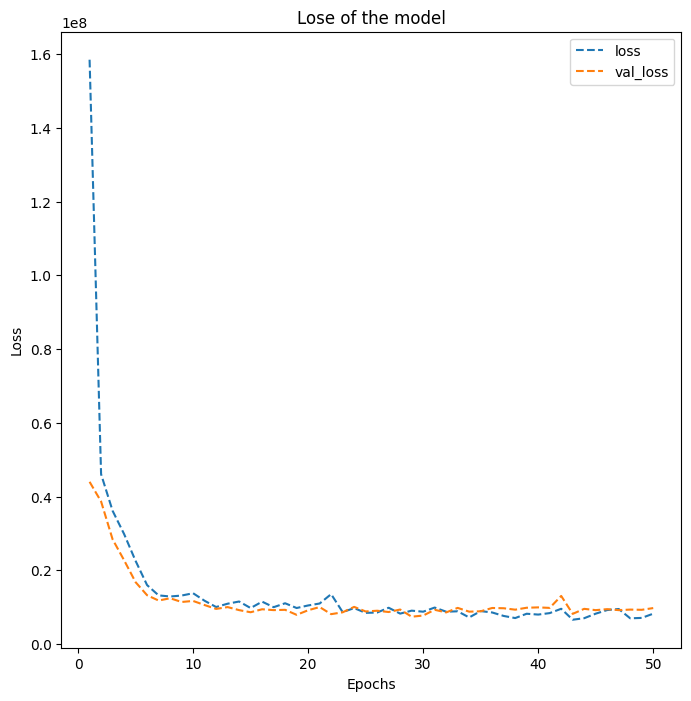

In [ ]:
# plotting the accuracies
skip=1
dict_hist = history.history
list_ep = [i for i in range(skip,epoch+1)]
# list_ep = [i for i in range(1,epoch+1)]

plt.figure(figsize = (8,8))
plt.plot(list_ep,dict_hist['loss'][(skip-1):],ls = '--', label = 'loss')
plt.plot(list_ep,dict_hist['val_loss'][(skip-1):],ls = '--', label = 'val_loss')
# plt.plot(list_ep,dict_hist['loss'],ls = '--', label = 'loss')
# plt.plot(list_ep,dict_hist['val_loss'],ls = '--', label = 'val_loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.yscale('linear')
plt.title('Lose of the model')
plt.legend()
plt.show()

##Score that Simple Linear Regression

In [ ]:
# get the MSE score of Linear Regression
predicted = x_model.predict(X)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")
# # Gets around 7.107 mil

We need to get a MSE better than 7107309.7162


In [ ]:
# get the MSE score of Linear Regression with p bigger than 0.3 removed
predicted = x_model_Pbigger3.predict(X_new_Pbigger3)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 7395836.6957


In [ ]:
# get the MSE score of Linear Regression with p bigger than 0.5 removed
predicted = x_model_Pbigger5.predict(X_new_Pbigger5)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 7255746.4066


## Score that Ridge CV

In [ ]:
# get the MSE score of RGD CV
x_model2 = linear_model.RidgeCV(alphas=[0.8, 1.0, 10.0])
x_model2.fit(X, y)
coeffs_XRCVr = np.array(list(x_model2.intercept_.flatten()) + list(x_model2.coef_.flatten()))
coeffs_XRCVr = list(coeffs_XRCVr)

predicted = x_model2.predict(X)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 7394603.2487


In [ ]:
# get the MSE score of RGD CV with p bigger than 0.3 removed
x_model2 = linear_model.RidgeCV(alphas=[0.8, 1.0, 10.0])
x_model2.fit(X_new_Pbigger3, y)
coeffs_XRCVr = np.array(list(x_model2.intercept_.flatten()) + list(x_model2.coef_.flatten()))
coeffs_XRCVr = list(coeffs_XRCVr)

predicted = x_model2.predict(X_new_Pbigger3)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 7540689.2918


In [ ]:
# get the MSE score of RGD CV with p bigger than 0.5 removed
x_model2 = linear_model.RidgeCV(alphas=[0.8, 1.0, 10.0])
x_model2.fit(X_new_Pbigger5, y)
coeffs_XRCVr = np.array(list(x_model2.intercept_.flatten()) + list(x_model2.coef_.flatten()))
coeffs_XRCVr = list(coeffs_XRCVr)

predicted = x_model2.predict(X_new_Pbigger5)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 7390408.9375


## Score that Elastic Net

In [ ]:
# get the MSE score of Elastic Net Regression
x_model3 = linear_model.ElasticNet(alpha=3.0, l1_ratio=0.9)
x_model3.fit(X, y)
coeffs_XENr = np.array(list(x_model3.intercept_.flatten()) + list(x_model3.coef_.flatten()))
coeffs_XENr = list(coeffs_XENr)

predicted = x_model3.predict(X)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 8183836.258


In [ ]:
# get the MSE score of Elastic Net Regression with p bigger than 0.3 removed
x_model3 = linear_model.ElasticNet(alpha=3.0, l1_ratio=0.9)
x_model3.fit(X_new_Pbigger3, y)
coeffs_XENr = np.array(list(x_model3.intercept_.flatten()) + list(x_model3.coef_.flatten()))
coeffs_XENr = list(coeffs_XENr)

predicted = x_model3.predict(X_new_Pbigger3)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 9527632.3809


In [ ]:
# get the MSE score of Elastic Net Regression with p bigger than 0.5 removed
x_model3 = linear_model.ElasticNet(alpha=3.0, l1_ratio=0.9)
x_model3.fit(X_new_Pbigger5, y)
coeffs_XENr = np.array(list(x_model3.intercept_.flatten()) + list(x_model3.coef_.flatten()))
coeffs_XENr = list(coeffs_XENr)

predicted = x_model3.predict(X_new_Pbigger5)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 9320441.7816


## Score that ARD Regression

In [ ]:
# get the MSE score of ARD Regression
x_model4 = linear_model.ARDRegression()
x_model4.fit(X, y)
coeffs_XARDr = np.array(list(x_model4.intercept_.flatten()) + list(x_model4.coef_.flatten()))
coeffs_XARDr = list(coeffs_XARDr)

predicted = x_model4.predict(X)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 7423041.9718


In [ ]:
# get the MSE score of ARD Regression with p bigger than 0.3 removed
x_model4 = linear_model.ARDRegression()
x_model4.fit(X_new_Pbigger3, y)
coeffs_XARDr = np.array(list(x_model4.intercept_.flatten()) + list(x_model4.coef_.flatten()))
coeffs_XARDr = list(coeffs_XARDr)

predicted = x_model4.predict(X_new_Pbigger3)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 7573336.6613


In [ ]:
# get the MSE score of ARD Regression with p bigger than 0.5 removed
x_model4 = linear_model.ARDRegression()
x_model4.fit(X_new_Pbigger5, y)
coeffs_XARDr = np.array(list(x_model4.intercept_.flatten()) + list(x_model4.coef_.flatten()))
coeffs_XARDr = list(coeffs_XARDr)

predicted = x_model4.predict(X_new_Pbigger5)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 7573332.0574


## Score that SGR Regression

In [ ]:
# get the MSE score of SGD Regression
x_model5 = linear_model.SGDRegressor()
x_model5.fit(X, y)
coeffs_XSGDr = np.array(list(x_model5.intercept_.flatten()) + list(x_model5.coef_.flatten()))
coeffs_XSGDr = list(coeffs_XSGDr)

predicted = x_model5.predict(X)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 7360460.9773


In [ ]:
# get the MSE score of SGD Regression with p bigger than 0.3 removed
x_model5 = linear_model.SGDRegressor()
x_model5.fit(X_new_Pbigger3, y)
coeffs_XSGDr = np.array(list(x_model5.intercept_.flatten()) + list(x_model5.coef_.flatten()))
coeffs_XSGDr = list(coeffs_XSGDr)

predicted = x_model5.predict(X_new_Pbigger3)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 3.0455652131742696e+32


In [ ]:
# get the MSE score of SGD Regression with p bigger than 0.5 removed
x_model5 = linear_model.SGDRegressor()
x_model5.fit(X_new_Pbigger5, y)
coeffs_XSGDr = np.array(list(x_model5.intercept_.flatten()) + list(x_model5.coef_.flatten()))
coeffs_XSGDr = list(coeffs_XSGDr)

predicted = x_model5.predict(X_new_Pbigger5)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"We need to get a MSE better than {MSE_SLR}")

We need to get a MSE better than 9.054380471406017e+32


After showing that simple linear regression is better, we can test it with all the different data sets that we separated from the whole dataset to see if there are any features that were making it worse,

In [ ]:
# get the MSE score of Linear Regression

x_model_zeroBetween = linear_model.LinearRegression()
x_model_zeroBetween.fit(X_new_zeroBetween, y)
coeffs_Xlr = np.array(list(x_model_zeroBetween.intercept_.flatten()) + list(x_model_zeroBetween.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_zeroBetween.score(X_new_zeroBetween, y), 4)
print("\nX zero between linear regression R-square :", Xlr_rsq)
print("\n")


x_model_tNegative = linear_model.LinearRegression()
x_model_tNegative.fit(X_new_tNegative, y)
coeffs_Xlr = np.array(list(x_model_tNegative.intercept_.flatten()) + list(x_model_tNegative.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_tNegative.score(X_new_tNegative, y), 4)
print("\nX t Negative linear regression R-square :", Xlr_rsq)
print("\n")


x_model_tSmall = linear_model.LinearRegression()
x_model_tSmall.fit(X_new_tSmall, y)
coeffs_Xlr = np.array(list(x_model_tSmall.intercept_.flatten()) + list(x_model_tSmall.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_tSmall.score(X_new_tSmall, y), 4)
print("\nX t Small linear regression R-square :", Xlr_rsq)
print("\n")


x_model_Pbigger5 = linear_model.LinearRegression()
x_model_Pbigger5.fit(X_new_Pbigger5, y)
coeffs_Xlr = np.array(list(x_model_Pbigger5.intercept_.flatten()) + list(x_model_Pbigger5.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_Pbigger5.score(X_new_Pbigger5, y), 4)
print("\nX P bigger than 0.5 linear regression R-square :", Xlr_rsq)
print("\n")


x_model_Pbigger3 = linear_model.LinearRegression()
x_model_Pbigger3.fit(X_new_Pbigger3, y)
coeffs_Xlr = np.array(list(x_model_Pbigger3.intercept_.flatten()) + list(x_model_Pbigger3.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_Pbigger3.score(X_new_Pbigger3, y), 4)
print("\nX P bigger than 0.3 linear regression R-square :", Xlr_rsq)
print("\n")


x_model_Pbigger1 = linear_model.LinearRegression()
x_model_Pbigger1.fit(X_new_Pbigger1, y)
coeffs_Xlr = np.array(list(x_model_Pbigger1.intercept_.flatten()) + list(x_model_Pbigger1.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_Pbigger1.score(X_new_Pbigger1, y), 4)
print("\nX P bigger than 0.1 linear regression R-square :", Xlr_rsq)
print("\n")


x_model_PbiggerO5 = linear_model.LinearRegression()
x_model_PbiggerO5.fit(X_new_PbiggerO5, y)
coeffs_Xlr = np.array(list(x_model_PbiggerO5.intercept_.flatten()) + list(x_model_PbiggerO5.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_PbiggerO5.score(X_new_PbiggerO5, y), 4)
print("\nX P bigger than 0.05 linear regression R-square :", Xlr_rsq)
print("\n")


x_model_Psmaller5 = linear_model.LinearRegression()
x_model_Psmaller5.fit(X_new_Psmaller5, y)
coeffs_Xlr = np.array(list(x_model_Psmaller5.intercept_.flatten()) + list(x_model_Psmaller5.coef_.flatten()))
coeffs_Xlr = list(coeffs_Xlr)
Xlr_rsq = round(x_model_Psmaller5.score(X_new_Psmaller5, y), 4)
print("\nX P smaller than 0.5 linear regression R-square :", Xlr_rsq)
print("\n")


predicted = x_model_zeroBetween.predict(X_new_zeroBetween)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"\nX zero between gets a MSE of {MSE_SLR}")

predicted = x_model_tNegative.predict(X_new_tNegative)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"\nX negative t gets a MSE of {MSE_SLR}")

predicted = x_model_tSmall.predict(X_new_tSmall)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"\nX small t gets a MSE of {MSE_SLR}")

predicted = x_model_Pbigger5.predict(X_new_Pbigger5)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"\nX P bigger than 0.5 gets a MSE of {MSE_SLR}")

predicted = x_model_Pbigger3.predict(X_new_Pbigger3)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"\nX P bigger than 0.3 gets a MSE of {MSE_SLR}")

predicted = x_model_Pbigger1.predict(X_new_Pbigger1)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"\nX P bigger than 0.1 gets a MSE of {MSE_SLR}")

predicted = x_model_PbiggerO5.predict(X_new_PbiggerO5)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"\nX P bigger than 0.05 gets a MSE of {MSE_SLR}")

predicted = x_model_Psmaller5.predict(X_new_Psmaller5)
error = (predicted - y)**2
MSE_SLR = round(error.mean(), 4)
print(f"\nX P smaller than 0.5 gets a MSE of {MSE_SLR}")


X zero between linear regression R-square : 0.8612



X t Negative linear regression R-square : 0.8653



X t Small linear regression R-square : 0.8632



X P bigger than 0.5 linear regression R-square : 0.8858



X P bigger than 0.3 linear regression R-square : 0.8835



X P bigger than 0.1 linear regression R-square : 0.832



X P bigger than 0.05 linear regression R-square : 0.829



X P smaller than 0.5 linear regression R-square : 0.3202



X zero between gets a MSE of 8814067.1586

X negative t gets a MSE of 8556432.8798

X small t gets a MSE of 8688871.792

X P bigger than 0.5 gets a MSE of 7255746.4066

X P bigger than 0.3 gets a MSE of 7395836.6957

X P bigger than 0.1 gets a MSE of 10667091.5712

X P bigger than 0.05 gets a MSE of 10861488.0532

X P smaller than 0.5 gets a MSE of 43172383.9172


##Score that we got from our model

In [ ]:
prediction = model_1.predict(X_train)
error = (prediction.T[0] - y_train)**2
MeanSquaredError = round(error.mean(), 4)
print(f'Mean Squared Error is {MeanSquaredError}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Mean Squared Error is 5149208.7987


In [ ]:
prediction = model_1.predict(X_test)
error = (prediction.T[0] - y_test)**2
MeanSquaredError = round(error.mean(), 4)
print(f'Mean Squared Error is {MeanSquaredError}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Mean Squared Error is 5994826.3459


In [ ]:
prediction = model_1.predict(X_val)
error = (prediction.T[0] - y_val)**2
MeanSquaredError = round(error.mean(), 4)
print(f'Mean Squared Error is {MeanSquaredError}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Mean Squared Error is 9738719.6727


add mse for validation set

add actual and predicted graph